# Distance & Probability-Based Models

**Two fundamentally different philosophies for making predictions:**

| Philosophy | Question asked | Core idea | Models |
|---|---|---|---|
| **Distance-Based** | "Who are my neighbours?" | Similar inputs → similar outputs | KNN |
| **Probability-Based** | "What is the most likely explanation?" | Use probability theory to classify | Naive Bayes |

**Scenario A — Distance-Based:**  
You are a clinic data scientist. A new patient comes in with vital-sign measurements. Your model asks: *"Find the 5 most similar patients we have seen before — what was their diagnosis?"*

**Scenario B — Probability-Based:**  
You are building an email spam filter. Your model asks: *"Given the words in this email, what is the probability it is spam?"*

| Section | Topic |
|---|---|
| 1 | Distance Metrics — The Mathematics of Similarity |
| 2 | K-Nearest Neighbors — Algorithm & Intuition |
| 3 | KNN Classification — Decision Boundaries |
| 4 | KNN Regression |
| 5 | The Scaling Problem |
| 6 | Choosing K — Validation Curve |
| 7 | The Curse of Dimensionality |
| 8 | Probability Review — Bayes' Theorem |
| 9 | Naive Bayes — The Independence Assumption |
| 10 | Gaussian Naive Bayes |
| 11 | Multinomial Naive Bayes (Text / Spam) |
| 12 | Kernel Density Estimation |
| 13 | KNN vs Naive Bayes — When to Use Which |
| 14 | Summary |

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, KernelDensity
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score, validation_curve
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Distance Metrics — The Mathematics of Similarity

Before KNN can find "nearest neighbours", we must define what **nearest** means. Different distance metrics make different geometric assumptions.

| Metric | Formula | When to use |
|---|---|---|
| **Euclidean** | $\sqrt{\sum_i (a_i - b_i)^2}$ | Continuous features, coordinates in space |
| **Manhattan** | $\sum_i \|a_i - b_i\|$ | Grid-like movement, robust to outliers |
| **Minkowski** | $\left(\sum_i \|a_i - b_i\|^p\right)^{1/p}$ | Generalisation (p=1: Manhattan, p=2: Euclidean) |
| **Cosine** | $1 - \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$ | Text data, direction matters more than magnitude |

In [2]:
# Compute distances between two patients
patient_A = np.array([45, 27.5, 120, 95])    # age, BMI, blood_pressure, glucose
patient_B = np.array([50, 30.0, 135, 110])
patient_C = np.array([46, 27.8, 122, 96])    # close to A

def euclidean(a, b): return np.sqrt(np.sum((a - b) ** 2))
def manhattan(a, b): return np.sum(np.abs(a - b))
def minkowski(a, b, p): return np.sum(np.abs(a - b) ** p) ** (1/p)
def cosine_dist(a, b): return 1 - np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print("Distances from Patient A:")
print(f"  {'Metric':>12}   {'A vs B':>10}   {'A vs C':>10}   Closer to A?")
print('  ' + '─' * 50)
for name, fn in [
    ('Euclidean', lambda a, b: euclidean(a, b)),
    ('Manhattan', lambda a, b: manhattan(a, b)),
    ('Minkowski3', lambda a, b: minkowski(a, b, 3)),
    ('Cosine',    lambda a, b: cosine_dist(a, b)),
]:
    d_ab = fn(patient_A, patient_B)
    d_ac = fn(patient_A, patient_C)
    closer = 'C' if d_ac < d_ab else 'B'
    print(f"  {name:>12}   {d_ab:>10.4f}   {d_ac:>10.4f}   {closer}")

Distances from Patient A:
        Metric       A vs B       A vs C   Closer to A?
  ──────────────────────────────────────────────────
     Euclidean      21.9374       2.4678   C
     Manhattan      37.5000       4.3000   C
    Minkowski3      19.0292       2.1564   C
        Cosine       0.0001       0.0000   C


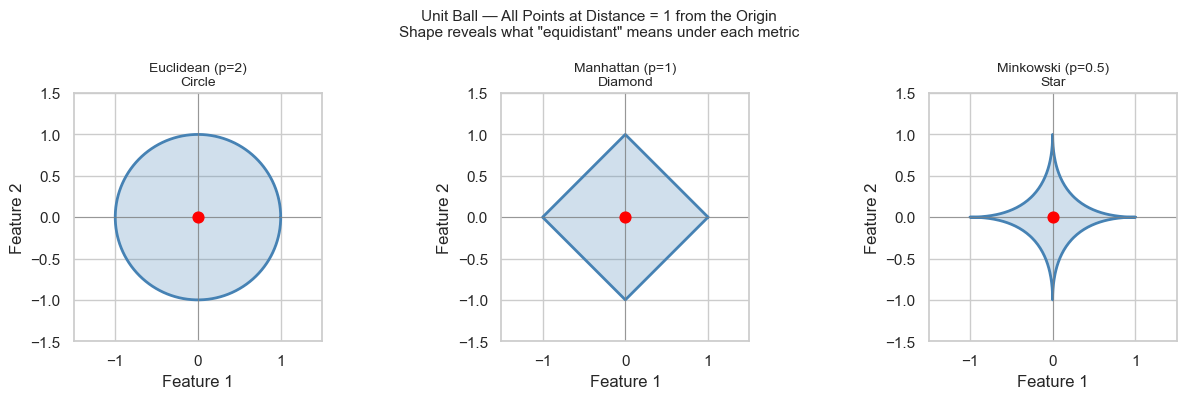

Key insight: The metric changes which points count as "equally close".
Manhattan treats axis-aligned movement as cheap; Euclidean treats all directions equally.


In [3]:
# Visualise unit balls for different distance metrics
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

theta = np.linspace(0, 2 * np.pi, 500)
metrics = [
    ('Euclidean (p=2)\nCircle', 2),
    ('Manhattan (p=1)\nDiamond', 1),
    ('Minkowski (p=0.5)\nStar', 0.5),
]

for ax, (label, p) in zip(axes, metrics):
    # Points on the unit ball: |x|^p + |y|^p = 1
    # Parametrically: x = sign(cos θ)|cos θ|^(2/p), y = sign(sin θ)|sin θ|^(2/p)
    x_ball = np.sign(np.cos(theta)) * np.abs(np.cos(theta)) ** (2/p)
    y_ball = np.sign(np.sin(theta)) * np.abs(np.sin(theta)) ** (2/p)

    ax.fill(x_ball, y_ball, alpha=0.25, color='steelblue')
    ax.plot(x_ball, y_ball, color='steelblue', lw=2)
    ax.scatter([0], [0], color='red', s=60, zorder=5)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Unit Ball — All Points at Distance = 1 from the Origin\n'
             'Shape reveals what "equidistant" means under each metric', fontsize=11)
plt.tight_layout()
plt.show()

print('Key insight: The metric changes which points count as "equally close".')
print('Manhattan treats axis-aligned movement as cheap; Euclidean treats all directions equally.')

---
## 2. K-Nearest Neighbors — Algorithm & Intuition

KNN is one of the simplest yet most powerful algorithms. It has **no training phase** — it memorises the entire dataset and predicts at query time.

### Algorithm — KNN Classification:
1. Given a new point $\mathbf{x}$
2. Compute the distance from $\mathbf{x}$ to every training point
3. Find the $k$ closest training points
4. Take a **majority vote** of their labels
5. Return the majority class as the prediction

### Algorithm — KNN Regression:
Steps 1–3 same. Step 4: take the **mean** (or weighted mean) of their target values.

> **KNN is a "lazy learner"** — it does no computation at training time. All computation happens at prediction time. This makes training fast but prediction slow for large datasets.

In [4]:
# Build the patient health dataset
N = 500

age            = np.random.normal(50, 15, N).clip(20, 80)
bmi            = np.random.normal(27, 5,  N).clip(15, 45)
blood_pressure = np.random.normal(120, 20, N).clip(70, 200)
glucose        = np.random.normal(100, 25, N).clip(50, 250)
cholesterol    = np.random.normal(200, 40, N).clip(100, 400)

# Risk score (higher = more at risk)
risk_score = (
    0.03 * age
    + 0.07 * bmi
    + 0.02 * blood_pressure
    + 0.04 * glucose
    + 0.01 * cholesterol
    + np.random.normal(0, 3, N)
)

# Assign risk class using quantile boundaries
risk_label = pd.qcut(risk_score, q=3, labels=[0, 1, 2]).astype(int)

df = pd.DataFrame({
    'age':            age.round(1),
    'bmi':            bmi.round(1),
    'blood_pressure': blood_pressure.round(0),
    'glucose':        glucose.round(0),
    'cholesterol':    cholesterol.round(0),
    'risk':           risk_label
})

risk_names = {0: 'Low', 1: 'Medium', 2: 'High'}
print(f'Dataset: {df.shape[0]} patients × {df.shape[1]} columns')
print()
print('Risk class distribution:')
for cls, cnt in df['risk'].value_counts().sort_index().items():
    print(f'  {cls} ({risk_names[cls]:>6}): {cnt} patients ({cnt/N*100:.1f}%)')
print()
df.head(8)

Dataset: 500 patients × 6 columns

Risk class distribution:
  0 (   Low): 167 patients (33.4%)
  1 (Medium): 166 patients (33.2%)
  2 (  High): 167 patients (33.4%)



,age,bmi,blood_pressure,glucose,cholesterol,risk
0,57.5,31.6,148.0,119.0,173.0,2
1,47.9,36.5,138.0,86.0,194.0,2
2,59.7,20.0,121.0,80.0,168.0,0
3,72.8,29.8,107.0,100.0,188.0,0
4,46.5,23.7,134.0,96.0,124.0,0
5,46.5,24.6,128.0,89.0,209.0,0
6,73.7,24.0,138.0,117.0,200.0,2
7,61.5,22.7,133.0,124.0,167.0,2


In [5]:
# Implement KNN from scratch for ONE test point (for pedagogical clarity)
def knn_predict_scratch(X_train, y_train, x_query, k=5, metric='euclidean'):
    """Step-by-step KNN prediction for a single query point."""
    # Step 1: Compute all distances
    if metric == 'euclidean':
        distances = np.sqrt(np.sum((X_train - x_query) ** 2, axis=1))
    elif metric == 'manhattan':
        distances = np.sum(np.abs(X_train - x_query), axis=1)

    # Step 2: Find k closest
    sorted_idx = np.argsort(distances)
    k_indices  = sorted_idx[:k]
    k_labels   = y_train[k_indices]
    k_dists    = distances[k_indices]

    # Step 3: Majority vote
    prediction = np.bincount(k_labels).argmax()

    return prediction, k_indices, k_labels, k_dists


# Use 2 features (glucose, BMI) so we can visualise easily
feat2 = ['glucose', 'bmi']
X2 = df[feat2].values
y2 = df['risk'].values

# New patient query
x_query = np.array([130.0, 32.0])   # glucose=130, BMI=32

pred, nn_idx, nn_labels, nn_dists = knn_predict_scratch(X2, y2, x_query, k=7)

print(f'Query patient: glucose={x_query[0]}, BMI={x_query[1]}')
print(f'7 nearest neighbours:')
print()
print(f"  {'Rank':>4}   {'glucose':>8}   {'BMI':>8}   {'Distance':>10}   {'Risk Label'}")
print('  ' + '─' * 50)
for rank, (idx, lbl, dist) in enumerate(zip(nn_idx, nn_labels, nn_dists), 1):
    print(f"  {rank:>4}   {X2[idx, 0]:>8.1f}   {X2[idx, 1]:>8.1f}   {dist:>10.3f}   {lbl} ({risk_names[lbl]})")

print()
votes = pd.Series(nn_labels).value_counts().sort_index()
print(f'Vote counts: {dict(votes)}   → Prediction: {pred} ({risk_names[pred]})')

Query patient: glucose=130.0, BMI=32.0
7 nearest neighbours:

  Rank    glucose        BMI     Distance   Risk Label
  ──────────────────────────────────────────────────
     1      130.0       30.6        1.400   2 (High)
     2      129.0       30.9        1.487   2 (High)
     3      133.0       30.5        3.354   2 (High)
     4      128.0       34.8        3.441   2 (High)
     5      132.0       28.8        3.774   2 (High)
     6      128.0       28.7        3.859   0 (Low)
     7      129.0       28.1        4.026   2 (High)

Vote counts: {0: np.int64(1), 2: np.int64(6)}   → Prediction: 2 (High)


---
## 3. KNN Classification — Decision Boundaries

The **decision boundary** is the region where the model switches its prediction from one class to another. For KNN:

- **Small k** (e.g., k=1): very jagged boundary — model is sensitive to every point → high variance
- **Large k** (e.g., k=50): smooth boundary — model ignores local structure → high bias

This is the bias-variance tradeoff again — now expressed through the choice of k.

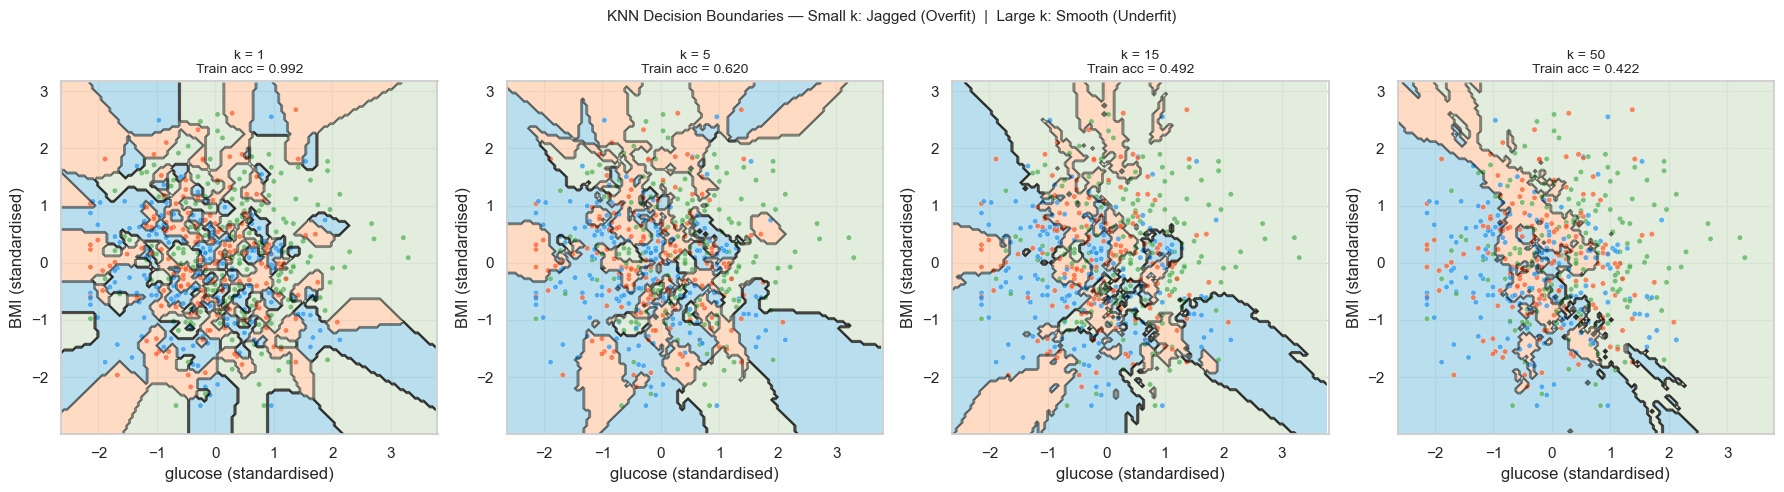

k=1:   Memorises every training point → perfect train accuracy, poor generalisation
k=5:   Smoother boundary, good for most datasets
k=50:  Very smooth, may miss local patterns → underfitting


In [6]:
# Plot decision boundaries for k = 1, 5, 15, 50
from matplotlib.colors import ListedColormap

scaler_2d = StandardScaler()
X2_s = scaler_2d.fit_transform(X2)

# Grid for the decision surface
h = 0.05
x_min, x_max = X2_s[:, 0].min() - 0.5, X2_s[:, 0].max() + 0.5
y_min, y_max = X2_s[:, 1].min() - 0.5, X2_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

k_values = [1, 5, 15, 50]
cmap_bg   = ListedColormap(['#a8d8ea', '#ffd3b6', '#dce9d5'])
cmap_pts  = ListedColormap(['#2196F3', '#FF5722', '#4CAF50'])

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X2_s, y2)

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.8)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.5)

    scatter = ax.scatter(X2_s[:, 0], X2_s[:, 1], c=y2, cmap=cmap_pts,
                         edgecolors='white', s=15, alpha=0.7, lw=0.3)

    train_acc = knn.score(X2_s, y2)
    ax.set_xlabel('glucose (standardised)')
    ax.set_ylabel('BMI (standardised)')
    ax.set_title(f'k = {k}\nTrain acc = {train_acc:.3f}', fontsize=10)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.suptitle('KNN Decision Boundaries — Small k: Jagged (Overfit)  |  Large k: Smooth (Underfit)',
             fontsize=11)
plt.tight_layout()
plt.show()

print('k=1:   Memorises every training point → perfect train accuracy, poor generalisation')
print('k=5:   Smoother boundary, good for most datasets')
print('k=50:  Very smooth, may miss local patterns → underfitting')

---
## 4. KNN Regression

KNN works for regression too — instead of majority vote, it averages the target values of the k nearest neighbours.

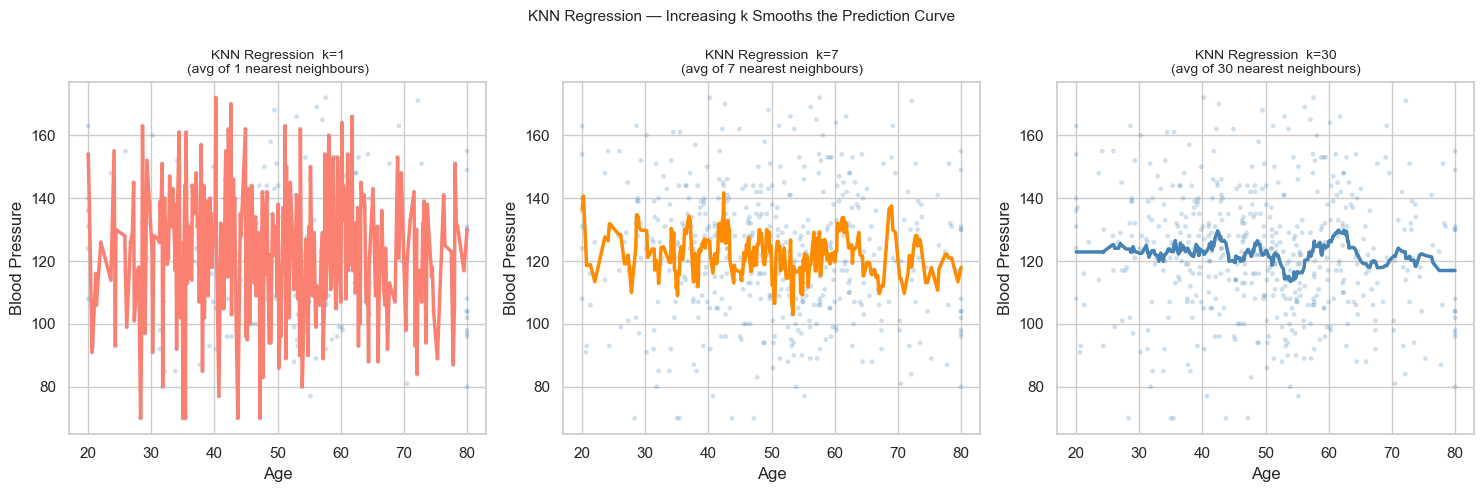

k=1:  Prediction = exact value of nearest neighbour → jagged, overfit
k=7:  Local average → smooth, captures trends
k=30: Global average → flat line → underfit


In [7]:
# Regression demo: predict blood pressure from age
x_reg = df['age'].values.reshape(-1, 1)
y_reg = df['blood_pressure'].values

x_sorted = np.sort(x_reg, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_vals_reg = [1, 7, 30]
colours    = ['salmon', 'darkorange', 'steelblue']

for ax, k, colour in zip(axes, k_vals_reg, colours):
    knn_r = KNeighborsRegressor(n_neighbors=k)
    knn_r.fit(x_reg, y_reg)

    y_smooth = knn_r.predict(x_sorted)

    ax.scatter(x_reg, y_reg, alpha=0.25, color='steelblue', s=12, edgecolors='none')
    ax.plot(x_sorted, y_smooth, color=colour, lw=2.5)
    ax.set_xlabel('Age')
    ax.set_ylabel('Blood Pressure')
    ax.set_title(f'KNN Regression  k={k}\n(avg of {k} nearest neighbours)', fontsize=10)

plt.suptitle('KNN Regression — Increasing k Smooths the Prediction Curve', fontsize=11)
plt.tight_layout()
plt.show()

print('k=1:  Prediction = exact value of nearest neighbour → jagged, overfit')
print('k=7:  Local average → smooth, captures trends')
print('k=30: Global average → flat line → underfit')

---
## 5. The Scaling Problem

KNN computes distances. If one feature has a much larger numeric range than another, it will **dominate** the distance calculation — the other features effectively stop mattering.

This is the most common KNN mistake. **Always scale before using KNN.**

In [8]:
# Demonstrate the scaling problem on the full feature set
feat_all = ['age', 'bmi', 'blood_pressure', 'glucose', 'cholesterol']
X_all = df[feat_all].values
y_all = df['risk'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25, random_state=42)

print('Feature ranges (Raw):')
for feat, vals in zip(feat_all, X_tr.T):
    print(f'  {feat:>16}:  [{vals.min():.0f}, {vals.max():.0f}]  (range = {vals.max()-vals.min():.0f})')

print()

# No scaling
knn_raw = KNeighborsClassifier(n_neighbors=7)
knn_raw.fit(X_tr, y_tr)
acc_raw = accuracy_score(y_te, knn_raw.predict(X_te))

# With StandardScaler
knn_scaled = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=7))
])
knn_scaled.fit(X_tr, y_tr)
acc_scaled = accuracy_score(y_te, knn_scaled.predict(X_te))

print(f'KNN (k=7) Accuracy:')
print(f'  Without scaling: {acc_raw:.4f}')
print(f'  With scaling:    {acc_scaled:.4f}   (better because all features contribute equally)')
print()

# Show how cholesterol dominates without scaling
pt_a = np.array([50, 27, 120, 100, 200])   # baseline
pt_b = np.array([50, 34, 120, 100, 201])   # BMI differs a lot, cholesterol barely
pt_c = np.array([50, 27, 120, 100, 280])   # cholesterol differs a lot

d_ab_raw = np.sqrt(np.sum((pt_a - pt_b)**2))
d_ac_raw = np.sqrt(np.sum((pt_a - pt_c)**2))

print('Distance comparison (raw, k=7):')
print(f'  A vs B (BMI differs by 7):           {d_ab_raw:.1f}')
print(f'  A vs C (cholesterol differs by 80):  {d_ac_raw:.1f}')
print()
print('Cholesterol (range 100-400) overwhelms BMI (range 15-45).')
print('Scaling fixes this: each feature contributes with equal weight.')

Feature ranges (Raw):
               age:  [20, 80]  (range = 60)
               bmi:  [15, 40]  (range = 25)
    blood_pressure:  [70, 172]  (range = 102)
           glucose:  [50, 180]  (range = 130)
       cholesterol:  [100, 324]  (range = 224)

KNN (k=7) Accuracy:
  Without scaling: 0.4480
  With scaling:    0.4640   (better because all features contribute equally)

Distance comparison (raw, k=7):
  A vs B (BMI differs by 7):           7.1
  A vs C (cholesterol differs by 80):  80.0

Cholesterol (range 100-400) overwhelms BMI (range 15-45).
Scaling fixes this: each feature contributes with equal weight.


---
## 6. Choosing K — Validation Curve

K is a hyperparameter. We choose it by evaluating model performance on held-out data for many values of K.

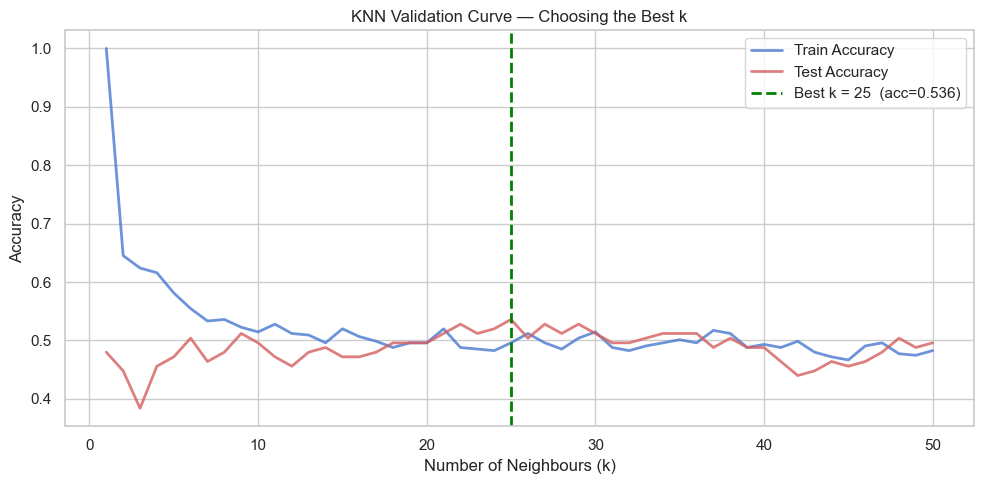

Best k = 25  (Test accuracy = 0.5360)

Pattern:
  k=1: perfect train acc (memorises data), lower test acc (overfitting)
  Increasing k: train acc drops, test acc rises (to a peak)
  Very large k: both drop (underfitting)


In [9]:
# Scale the data first
scaler_all = StandardScaler()
X_tr_s = scaler_all.fit_transform(X_tr)
X_te_s = scaler_all.transform(X_te)

k_range = range(1, 51)
train_accs = []
test_accs  = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_s, y_tr)
    train_accs.append(accuracy_score(y_tr, knn.predict(X_tr_s)))
    test_accs.append(accuracy_score(y_te, knn.predict(X_te_s)))

best_k   = k_range.start + np.argmax(test_accs)
best_acc = max(test_accs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), train_accs, 'b-', lw=2, label='Train Accuracy', alpha=0.8)
ax.plot(list(k_range), test_accs,  'r-', lw=2, label='Test Accuracy',  alpha=0.8)
ax.axvline(best_k, color='green', ls='--', lw=2, label=f'Best k = {best_k}  (acc={best_acc:.3f})')
ax.set_xlabel('Number of Neighbours (k)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN Validation Curve — Choosing the Best k')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best k = {best_k}  (Test accuracy = {best_acc:.4f})')
print()
print('Pattern:')
print('  k=1: perfect train acc (memorises data), lower test acc (overfitting)')
print('  Increasing k: train acc drops, test acc rises (to a peak)')
print('  Very large k: both drop (underfitting)')

---
## 7. The Curse of Dimensionality

KNN relies on the idea that "nearby" points share similar labels. But in high dimensions, this breaks down:

> In high-dimensional space, **all points become equally distant** from each other. There are no meaningful "nearest neighbours".

**Intuition:** In 1D, the nearest of 10 points is typically very close. In 1000D, even the nearest of 10 million points may be far away.

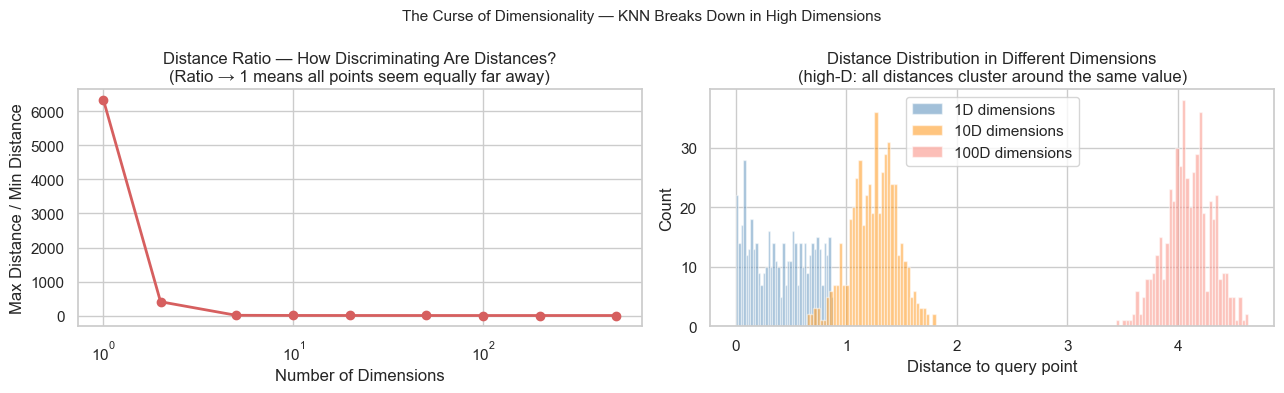

In 1D: nearest neighbour is meaningfully close; farthest is far away (large ratio).
In 100D: ALL points appear roughly equidistant → nearest neighbour is not really "near".

Practical limit: KNN works well up to ~20-30 features.
For high-dimensional data: apply PCA (Principal Component Analysis) first, or use a different model.


In [10]:
# Show how min/max distances converge as dimensions increase
n_points = 1000
dims = [1, 2, 5, 10, 20, 50, 100, 200, 500]

dist_ratios = []    # max_dist / min_dist — measures how "concentrated" distances are

for d in dims:
    X_hd = np.random.uniform(0, 1, (n_points, d))
    # Distance from the first point to all others
    dists = np.sqrt(np.sum((X_hd[1:] - X_hd[0]) ** 2, axis=1))
    ratio = dists.max() / (dists.min() + 1e-10)
    dist_ratios.append(ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(dims, dist_ratios, 'r-o', lw=2, ms=6)
axes[0].set_xlabel('Number of Dimensions')
axes[0].set_ylabel('Max Distance / Min Distance')
axes[0].set_title('Distance Ratio — How Discriminating Are Distances?\n'
                  '(Ratio → 1 means all points seem equally far away)')

# Show: in 1D vs 100D, what the distances look like
for d, colour, lbl in [(1, 'steelblue', '1D'), (10, 'darkorange', '10D'), (100, 'salmon', '100D')]:
    X_temp = np.random.uniform(0, 1, (500, d))
    dists_temp = np.sqrt(np.sum((X_temp[1:] - X_temp[0]) ** 2, axis=1))
    axes[1].hist(dists_temp, bins=40, alpha=0.5, color=colour, label=f'{lbl} dimensions')

axes[1].set_xlabel('Distance to query point')
axes[1].set_ylabel('Count')
axes[1].set_title('Distance Distribution in Different Dimensions\n'
                  '(high-D: all distances cluster around the same value)')
axes[1].legend()

plt.suptitle('The Curse of Dimensionality — KNN Breaks Down in High Dimensions', fontsize=11)
plt.tight_layout()
plt.show()

print('In 1D: nearest neighbour is meaningfully close; farthest is far away (large ratio).')
print('In 100D: ALL points appear roughly equidistant → nearest neighbour is not really "near".')
print()
print('Practical limit: KNN works well up to ~20-30 features.')
print('For high-dimensional data: apply PCA (Principal Component Analysis) first, or use a different model.')

---
## 8. Probability Review — Bayes' Theorem

### Key Probability Concepts

| Term | Notation | Meaning |
|---|---|---|
| **Prior** | $P(C)$ | Probability of class $C$ before seeing any data |
| **Likelihood** | $P(\mathbf{x} \mid C)$ | Probability of observing features $\mathbf{x}$ given class $C$ |
| **Posterior** | $P(C \mid \mathbf{x})$ | Probability of class $C$ given we observed $\mathbf{x}$ — what we want! |
| **Evidence** | $P(\mathbf{x})$ | Probability of observing $\mathbf{x}$ at all (normalisation constant) |

**Bayes' Theorem:**

$$P(C \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid C) \cdot P(C)}{P(\mathbf{x})}$$

$$\text{Posterior} = \frac{\text{Likelihood} \times \text{Prior}}{\text{Evidence}}$$

In [11]:
# Concrete Bayes' Theorem example: medical screening
# Disease prevalence = 1%
# Test sensitivity (true positive rate) = 95%
# Test specificity (true negative rate) = 90%

P_disease     = 0.01    # Prior: 1% have the disease
P_no_disease  = 0.99
P_pos_given_D = 0.95    # Likelihood: test positive given disease
P_pos_given_ND = 0.10   # Likelihood: test positive given NO disease (false positive rate)

# Total probability of a positive test
P_positive = P_pos_given_D * P_disease + P_pos_given_ND * P_no_disease

# Bayes: P(disease | positive test)
P_disease_given_pos = (P_pos_given_D * P_disease) / P_positive

print('Medical Screening — Bayes\' Theorem in Action')
print('=' * 50)
print(f'  Disease prevalence (Prior):         {P_disease*100:.1f}%')
print(f'  Test sensitivity (P(+|Disease)):    {P_pos_given_D*100:.1f}%')
print(f'  False positive rate (P(+|Healthy)): {P_pos_given_ND*100:.1f}%')
print()
print(f'  P(positive test) = {P_positive*100:.2f}%')
print()
print(f'  P(Disease | Positive Test) = {P_disease_given_pos*100:.1f}%')
print()
print('SURPRISING RESULT: Even with a 95% accurate test, a positive result')
print(f'means only {P_disease_given_pos*100:.1f}% chance of actually having the disease!')
print()
print('Why? Because the disease is rare (1%). Most positive tests come from the')
print('10% false positive rate among the large healthy population.')

Medical Screening — Bayes' Theorem in Action
  Disease prevalence (Prior):         1.0%
  Test sensitivity (P(+|Disease)):    95.0%
  False positive rate (P(+|Healthy)): 10.0%

  P(positive test) = 10.85%

  P(Disease | Positive Test) = 8.8%

SURPRISING RESULT: Even with a 95% accurate test, a positive result
means only 8.8% chance of actually having the disease!

Why? Because the disease is rare (1%). Most positive tests come from the
10% false positive rate among the large healthy population.


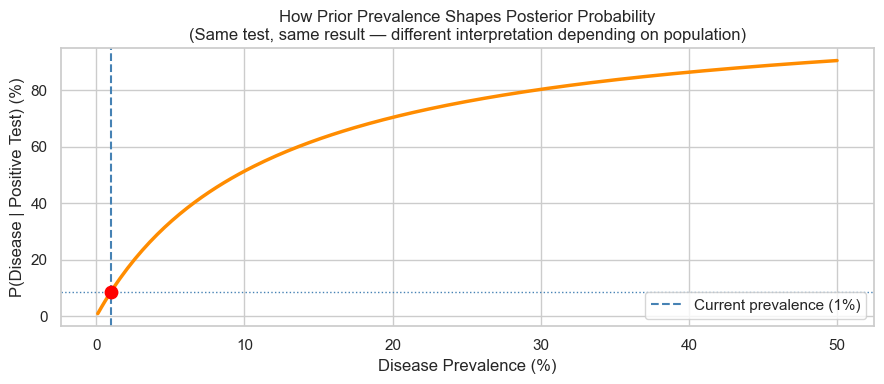

Key insight: The posterior depends heavily on the prior.
A test designed for a rare disease gives many false alarms.
The same test on a high-risk population gives far more reliable results.


In [12]:
# Visualise how prior prevalence changes the posterior
prevalences = np.linspace(0.001, 0.5, 200)

posteriors = [
    (P_pos_given_D * prev) / (P_pos_given_D * prev + P_pos_given_ND * (1 - prev))
    for prev in prevalences
]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(prevalences * 100, np.array(posteriors) * 100, color='darkorange', lw=2.5)
ax.axvline(1, color='steelblue', ls='--', lw=1.5, label='Current prevalence (1%)')
ax.axhline(P_disease_given_pos * 100, color='steelblue', ls=':', lw=1)
ax.scatter([1], [P_disease_given_pos * 100], color='red', s=80, zorder=5)
ax.set_xlabel('Disease Prevalence (%)')
ax.set_ylabel('P(Disease | Positive Test) (%)')
ax.set_title('How Prior Prevalence Shapes Posterior Probability\n'
             '(Same test, same result — different interpretation depending on population)')
ax.legend()
plt.tight_layout()
plt.show()

print('Key insight: The posterior depends heavily on the prior.')
print('A test designed for a rare disease gives many false alarms.')
print('The same test on a high-risk population gives far more reliable results.')

---
## 9. Naive Bayes — The Independence Assumption

**Goal:** Classify a new email as spam or not-spam given its words.

Applying Bayes' theorem:

$$P(\text{Spam} \mid \mathbf{x}) \propto P(\mathbf{x} \mid \text{Spam}) \cdot P(\text{Spam})$$

**The problem:** $P(\mathbf{x} \mid \text{Spam}) = P(x_1, x_2, \ldots, x_p \mid \text{Spam})$ is a joint probability over all word combinations — intractable for thousands of words.

**The "Naive" assumption:** Assume all features are **conditionally independent** given the class:

$$P(x_1, x_2, \ldots, x_p \mid C) \approx \prod_{j=1}^{p} P(x_j \mid C)$$

This is "naive" because word co-occurrences are obviously not independent in real language. Yet the model works surprisingly well in practice.

The full classification rule becomes:

$$\hat{C} = \arg\max_C \; P(C) \prod_{j=1}^{p} P(x_j \mid C)$$

In [13]:
# Manual Naive Bayes calculation — spam detection
# 4 training emails:
#   Email 1: "win free money" → Spam
#   Email 2: "free prize win" → Spam
#   Email 3: "meeting schedule project" → Ham
#   Email 4: "project report schedule" → Ham

# Vocabulary: win, free, money, prize, meeting, schedule, project, report
vocab = ['win', 'free', 'money', 'prize', 'meeting', 'schedule', 'project', 'report']

# Training counts (rows = emails, cols = word counts)
spam_emails = [
    [1, 1, 1, 0, 0, 0, 0, 0],   # win free money
    [1, 1, 0, 1, 0, 0, 0, 0],   # free prize win
]
ham_emails = [
    [0, 0, 0, 0, 1, 1, 1, 0],   # meeting schedule project
    [0, 0, 0, 0, 0, 1, 1, 1],   # project report schedule
]

spam_arr = np.array(spam_emails)
ham_arr  = np.array(ham_emails)

# Priors
P_spam = len(spam_emails) / (len(spam_emails) + len(ham_emails))
P_ham  = 1 - P_spam

# Likelihoods with Laplace smoothing (add 1 to each count)
spam_word_counts = spam_arr.sum(axis=0) + 1  # Laplace smoothing
ham_word_counts  = ham_arr.sum(axis=0)  + 1

P_word_given_spam = spam_word_counts / spam_word_counts.sum()
P_word_given_ham  = ham_word_counts  / ham_word_counts.sum()

# New email: "free money report"
new_email = np.array([0, 1, 1, 0, 0, 0, 0, 1])

# Log probabilities (avoid underflow)
log_P_spam_given_email = np.log(P_spam) + np.sum(new_email * np.log(P_word_given_spam))
log_P_ham_given_email  = np.log(P_ham)  + np.sum(new_email * np.log(P_word_given_ham))

print('Manual Naive Bayes — "free money report"')
print(f'  P(Spam) = {P_spam:.2f},  P(Ham) = {P_ham:.2f}')
print()
print('  Word likelihoods given class:')
print(f"  {'Word':>10}   {'P(w|Spam)':>10}   {'P(w|Ham)':>10}   In email?")
print('  ' + '─' * 48)
for word, ps, ph, in_email in zip(vocab, P_word_given_spam, P_word_given_ham, new_email):
    flag = '  ← this word' if in_email else ''
    print(f"  {word:>10}   {ps:>10.4f}   {ph:>10.4f}{flag}")

print()
print(f'  log P(Spam | email) ∝ {log_P_spam_given_email:.4f}')
print(f'  log P(Ham  | email) ∝ {log_P_ham_given_email:.4f}')
print()
prediction = 'SPAM' if log_P_spam_given_email > log_P_ham_given_email else 'HAM'
print(f'  → Predicted class: {prediction}')

Manual Naive Bayes — "free money report"
  P(Spam) = 0.50,  P(Ham) = 0.50

  Word likelihoods given class:
        Word    P(w|Spam)     P(w|Ham)   In email?
  ────────────────────────────────────────────────
         win       0.2143       0.0714
        free       0.2143       0.0714  ← this word
       money       0.1429       0.0714  ← this word
       prize       0.1429       0.0714
     meeting       0.0714       0.1429
    schedule       0.0714       0.2143
     project       0.0714       0.2143
      report       0.0714       0.1429  ← this word

  log P(Spam | email) ∝ -6.8186
  log P(Ham  | email) ∝ -7.9172

  → Predicted class: SPAM


---
## 10. Gaussian Naive Bayes — Continuous Features

When features are continuous, we model each feature as a **Gaussian (normal) distribution** within each class:

$$P(x_j \mid C) = \frac{1}{\sqrt{2\pi\sigma_{jC}^2}} \exp\left(-\frac{(x_j - \mu_{jC})^2}{2\sigma_{jC}^2}\right)$$

The model estimates $\mu_{jC}$ and $\sigma_{jC}$ from the training data (mean and std of feature $j$ for class $C$).

In [14]:
# Gaussian NB on the patient health dataset
X_all = df[feat_all].values
y_all = df['risk'].values

X_tr_nb, X_te_nb, y_tr_nb, y_te_nb = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)

gnb = GaussianNB()
gnb.fit(X_tr_nb, y_tr_nb)

y_pred_gnb = gnb.predict(X_te_nb)
acc_gnb = accuracy_score(y_te_nb, y_pred_gnb)

print(f'Gaussian Naive Bayes — Test Accuracy: {acc_gnb:.4f}')
print()
print('Learned class means (μ) per class:')
print(f"  {'Feature':>16}   {'Low (μ)':>10}   {'Medium (μ)':>12}   {'High (μ)':>10}")
print('  ' + '─' * 55)
for j, feat in enumerate(feat_all):
    means = gnb.theta_[:, j]  # theta_ = class means
    print(f"  {feat:>16}   {means[0]:>10.1f}   {means[1]:>12.1f}   {means[2]:>10.1f}")

Gaussian Naive Bayes — Test Accuracy: 0.4640

Learned class means (μ) per class:
           Feature      Low (μ)     Medium (μ)     High (μ)
  ───────────────────────────────────────────────────────
               age         48.2           48.9         52.5
               bmi         26.4           27.2         27.8
    blood_pressure        119.5          119.2        125.7
           glucose         93.3           98.4        110.7
       cholesterol        189.7          204.3        198.9


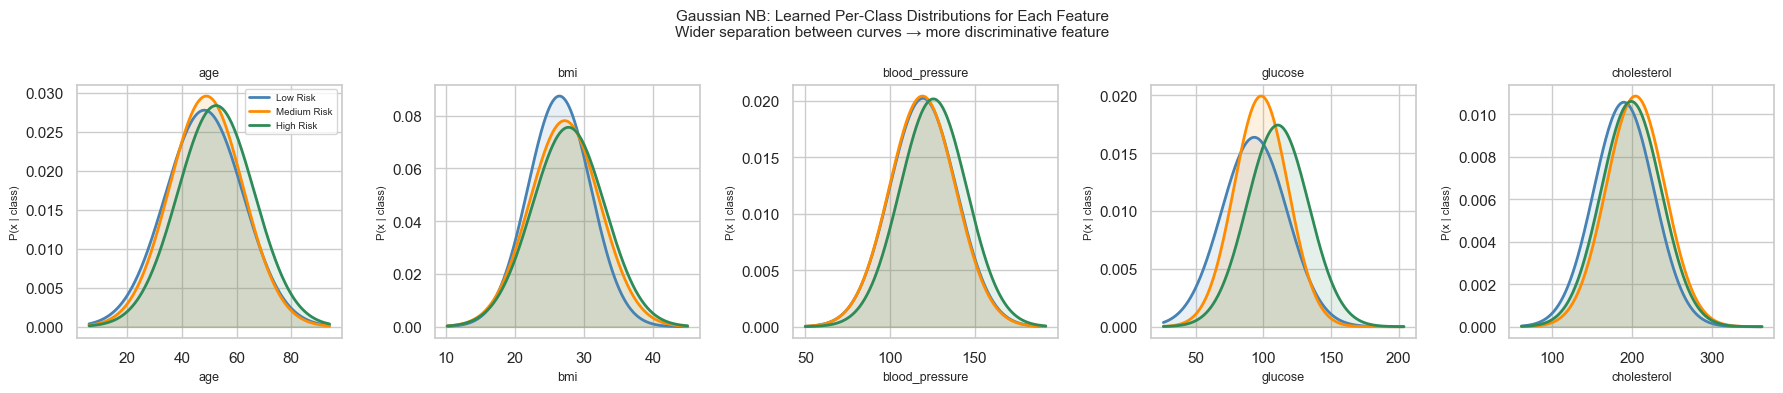

When a feature's per-class distributions overlap a lot → not very useful for discrimination.
When they are well-separated → strong discriminative power.


In [15]:
# Visualise: per-class Gaussian distributions for each feature
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colours = ['steelblue', 'darkorange', 'seagreen']
labels  = ['Low Risk', 'Medium Risk', 'High Risk']

for ax, feat, j in zip(axes, feat_all, range(5)):
    x_plot = np.linspace(
        df[feat].min() - df[feat].std(),
        df[feat].max() + df[feat].std(),
        300
    )
    for cls, colour, label in zip([0, 1, 2], colours, labels):
        mu  = gnb.theta_[cls, j]
        sig = np.sqrt(gnb.var_[cls, j])
        pdf = stats.norm.pdf(x_plot, mu, sig)
        ax.plot(x_plot, pdf, color=colour, lw=2, label=label)
        ax.fill_between(x_plot, pdf, alpha=0.12, color=colour)

    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('P(x | class)', fontsize=8)
    ax.set_title(feat, fontsize=9)
    if j == 0:
        ax.legend(fontsize=7)

plt.suptitle('Gaussian NB: Learned Per-Class Distributions for Each Feature\n'
             'Wider separation between curves → more discriminative feature', fontsize=11)
plt.tight_layout()
plt.show()

print('When a feature\'s per-class distributions overlap a lot → not very useful for discrimination.')
print('When they are well-separated → strong discriminative power.')

---
## 11. Multinomial Naive Bayes — Text & Spam Classification

For **count data** (word frequencies), we use the Multinomial distribution:

$$P(\mathbf{x} \mid C) = \frac{(\sum_j x_j)!}{\prod_j x_j!} \prod_j \theta_{jC}^{x_j}$$

where $\theta_{jC}$ = probability that a word is $j$ given class $C$.

**Laplace smoothing** prevents zero probabilities for words not seen in training:

$$\hat{\theta}_{jC} = \frac{\text{count}(j, C) + \alpha}{\text{total words in C} + \alpha \cdot |V|}$$

In [16]:
# Create the spam email dataset
N_spam = 320
N_ham  = 480

word_cols = ['word_free', 'word_money', 'word_win', 'word_urgent',
             'word_click', 'word_meeting', 'word_report', 'word_project']

spam_rates = [3.0, 2.5, 2.0, 1.8, 2.2, 0.2, 0.3, 0.2]
ham_rates  = [0.2, 0.3, 0.1, 0.2, 0.3, 2.5, 2.0, 1.8]

spam_data = np.column_stack([np.random.poisson(r, N_spam) for r in spam_rates])
ham_data  = np.column_stack([np.random.poisson(r, N_ham)  for r in ham_rates])

X_email = np.vstack([spam_data, ham_data])
y_email = np.concatenate([np.ones(N_spam, dtype=int), np.zeros(N_ham, dtype=int)])

df_email = pd.DataFrame(X_email, columns=word_cols)
df_email['label'] = y_email

print(f'Email dataset: {len(df_email)} emails')
print(f'  Spam: {N_spam}  ({N_spam/(N_spam+N_ham)*100:.1f}%)')
print(f'  Ham:  {N_ham}  ({N_ham/(N_spam+N_ham)*100:.1f}%)')
print()

# Average word counts per class
print('Mean word count per email:')
means = df_email.groupby('label')[word_cols].mean().round(2)
means.index = ['Ham', 'Spam']
print(means.to_string())

Email dataset: 800 emails
  Spam: 320  (40.0%)
  Ham:  480  (60.0%)

Mean word count per email:
      word_free  word_money  word_win  word_urgent  word_click  word_meeting  word_report  word_project
Ham        0.23        0.26      0.10         0.19        0.27          2.45         2.04          1.78
Spam       2.92        2.31      1.81         1.83        2.17          0.21         0.32          0.18


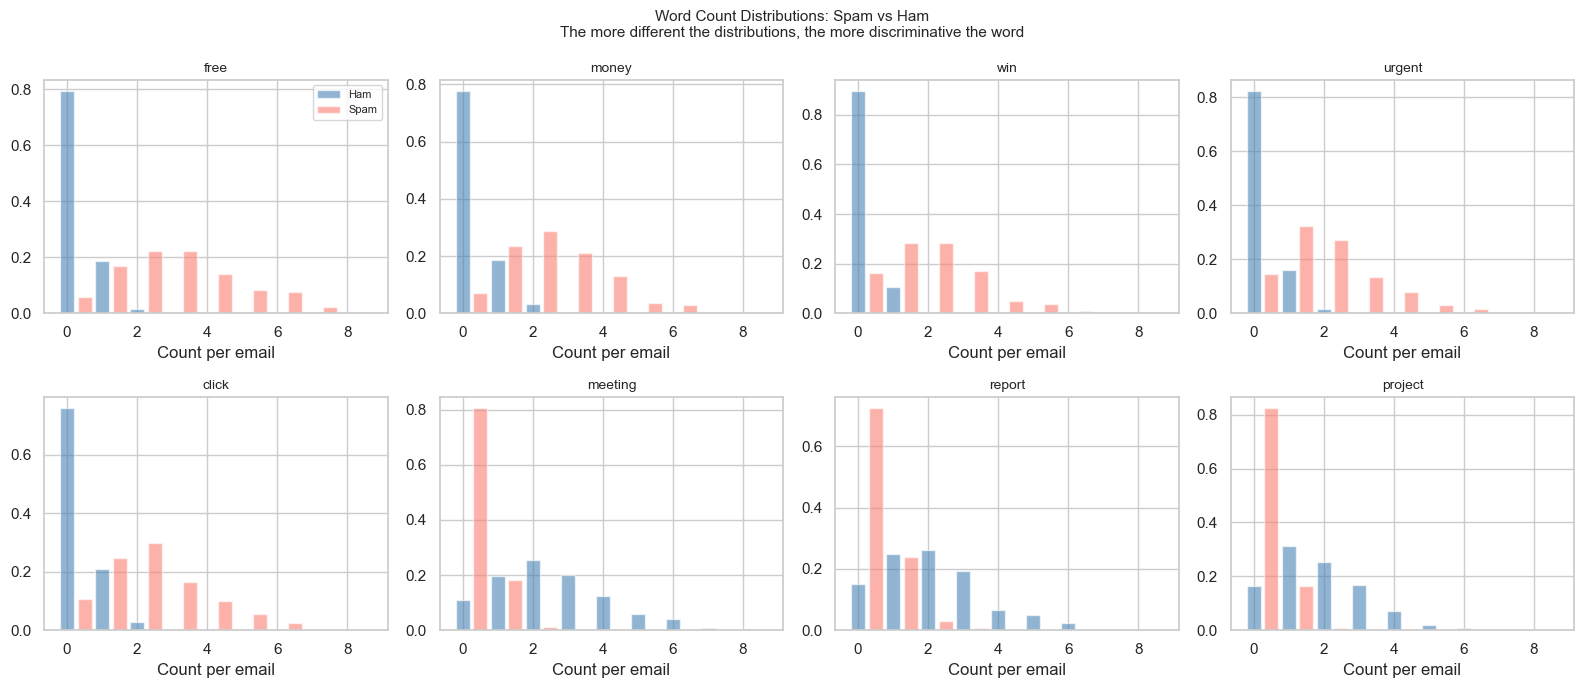

In [17]:
# Visualise: word count distributions for spam vs ham
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, word in zip(axes, word_cols):
    spam_counts = df_email[df_email['label'] == 1][word]
    ham_counts  = df_email[df_email['label'] == 0][word]

    ax.hist(ham_counts,  bins=range(0, 10), alpha=0.6, color='steelblue',
            label='Ham',  density=True, rwidth=0.4, align='left')
    ax.hist(spam_counts, bins=range(0, 10), alpha=0.6, color='salmon',
            label='Spam', density=True, rwidth=0.4, align='mid')
    ax.set_title(word.replace('word_', ''), fontsize=10)
    ax.set_xlabel('Count per email')
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.suptitle('Word Count Distributions: Spam vs Ham\n'
             'The more different the distributions, the more discriminative the word', fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
# Train and evaluate Multinomial NB
Xe_tr, Xe_te, ye_tr, ye_te = train_test_split(
    X_email, y_email, test_size=0.25, random_state=42, stratify=y_email
)

mnb = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing
mnb.fit(Xe_tr, ye_tr)

ye_pred = mnb.predict(Xe_te)
ye_prob = mnb.predict_proba(Xe_te)[:, 1]

print('Multinomial Naive Bayes — Spam Classifier:')
print(classification_report(ye_te, ye_pred, target_names=['Ham', 'Spam']))

# Show feature log-probabilities (what the model learned)
print('Learned log-probabilities (log θ) per word per class:')
print(f"{'Word':>15}   {'P(w|Ham)':>10}   {'P(w|Spam)':>12}   {'Spam/Ham Ratio':>15}")
print('─' * 58)
for j, word in enumerate(word_cols):
    p_ham  = np.exp(mnb.feature_log_prob_[0, j])
    p_spam = np.exp(mnb.feature_log_prob_[1, j])
    ratio  = p_spam / (p_ham + 1e-10)
    flag   = '  ← strong spam signal' if ratio > 5 else ('  ← ham signal' if ratio < 0.3 else '')
    w = word.replace('word_', '')
    print(f"{w:>15}   {p_ham:>10.4f}   {p_spam:>12.4f}   {ratio:>15.2f}x{flag}")

Multinomial Naive Bayes — Spam Classifier:
              precision    recall  f1-score   support

         Ham       1.00      0.99      1.00       120
        Spam       0.99      1.00      0.99        80

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200

Learned log-probabilities (log θ) per word per class:
           Word     P(w|Ham)      P(w|Spam)    Spam/Ham Ratio
──────────────────────────────────────────────────────────
           free       0.0336         0.2567              7.63x  ← strong spam signal
          money       0.0344         0.1947              5.66x  ← strong spam signal
            win       0.0149         0.1467              9.85x  ← strong spam signal
         urgent       0.0260         0.1619              6.23x  ← strong spam signal
          click       0.0336         0.1802              5.36x  ← strong spam signal
        meeting       0.3206  

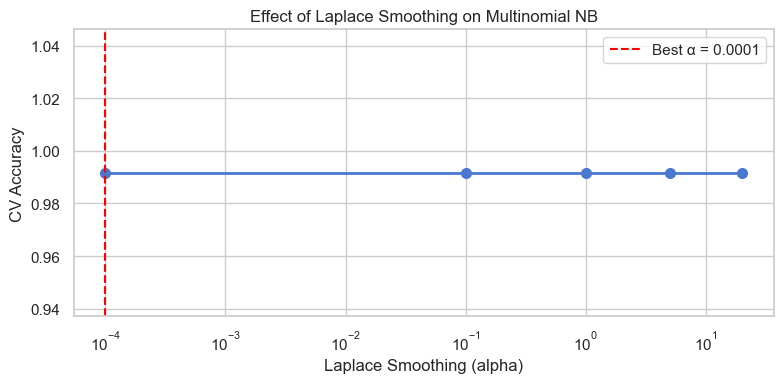

Alpha = 0: no smoothing → zero probabilities for unseen words → model crashes on new vocabulary
Alpha = 1: standard Laplace smoothing → adds 1 pseudo-count to each word
Large alpha: strong smoothing → all words treated more equally → underfitting


In [19]:
# Effect of Laplace smoothing (alpha)
alphas = [0.0001, 0.1, 1.0, 5.0, 20.0]

cv_scores = []
for a in alphas:
    scores = cross_val_score(MultinomialNB(alpha=a), Xe_tr, ye_tr, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, cv_scores, 'b-o', lw=2, ms=7)
best_a = alphas[np.argmax(cv_scores)]
ax.axvline(best_a, color='red', ls='--', label=f'Best α = {best_a}')
ax.set_xlabel('Laplace Smoothing (alpha)')
ax.set_ylabel('CV Accuracy')
ax.set_title('Effect of Laplace Smoothing on Multinomial NB')
ax.legend()
plt.tight_layout()
plt.show()

print('Alpha = 0: no smoothing → zero probabilities for unseen words → model crashes on new vocabulary')
print('Alpha = 1: standard Laplace smoothing → adds 1 pseudo-count to each word')
print('Large alpha: strong smoothing → all words treated more equally → underfitting')

---
## 12. Kernel Density Estimation — Estimating Probability Density

KDE bridges distance-based and probability-based thinking:
- **Gaussian NB** assumes each class follows a single Gaussian — too restrictive
- **KDE** estimates the density non-parametrically by placing a "kernel" around each data point

$$\hat{f}(x) = \frac{1}{n \cdot h} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

where $K$ is the kernel function and $h$ is the **bandwidth** (analogous to k in KNN).

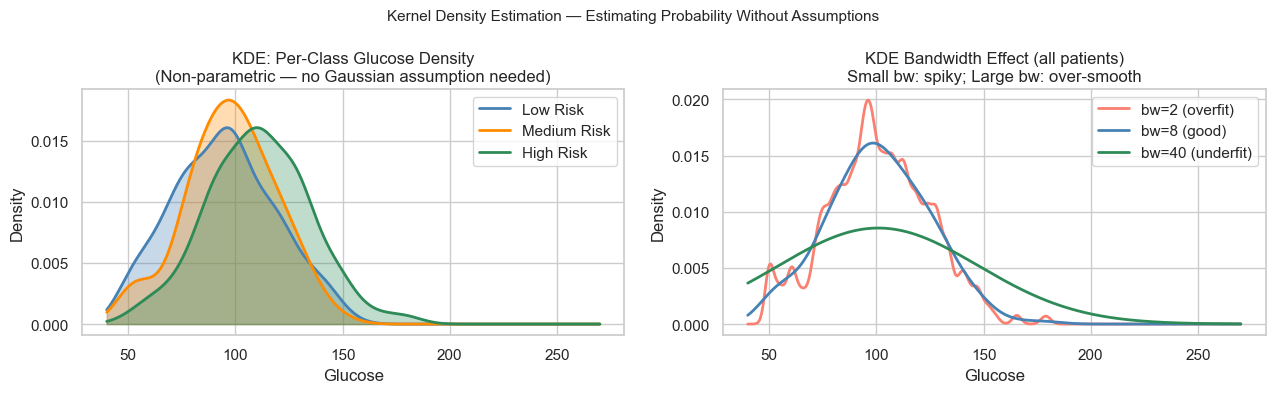

KDE with small bandwidth ≈ like KNN with k=1: fits every noise bump
KDE with large bandwidth ≈ like KNN with large k: smooth but misses structure
Optimal bandwidth: choose via cross-validation


In [20]:
# KDE on glucose by risk class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colours = ['steelblue', 'darkorange', 'seagreen']
labels  = ['Low Risk', 'Medium Risk', 'High Risk']
x_plot  = np.linspace(40, 270, 500).reshape(-1, 1)

for cls, colour, label in zip([0, 1, 2], colours, labels):
    data = df[df['risk'] == cls]['glucose'].values.reshape(-1, 1)

    # Gaussian kernel, bandwidth=8
    kde = KernelDensity(kernel='gaussian', bandwidth=8)
    kde.fit(data)
    log_dens = kde.score_samples(x_plot)
    axes[0].fill_between(x_plot.ravel(), np.exp(log_dens), alpha=0.3, color=colour)
    axes[0].plot(x_plot, np.exp(log_dens), lw=2, color=colour, label=label)

axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('Density')
axes[0].set_title('KDE: Per-Class Glucose Density\n(Non-parametric — no Gaussian assumption needed)')
axes[0].legend()

# Bandwidth effect
data_bw = df['glucose'].values.reshape(-1, 1)
for bw, colour, lbl in [(2, 'salmon', 'bw=2 (overfit)'),
                        (8, 'steelblue', 'bw=8 (good)'),
                        (40, 'seagreen', 'bw=40 (underfit)')]:
    kde_bw = KernelDensity(kernel='gaussian', bandwidth=bw)
    kde_bw.fit(data_bw)
    dens = np.exp(kde_bw.score_samples(x_plot))
    axes[1].plot(x_plot, dens, lw=2, color=colour, label=lbl)

axes[1].set_xlabel('Glucose')
axes[1].set_ylabel('Density')
axes[1].set_title('KDE Bandwidth Effect (all patients)\n'
                  'Small bw: spiky; Large bw: over-smooth')
axes[1].legend()

plt.suptitle('Kernel Density Estimation — Estimating Probability Without Assumptions', fontsize=11)
plt.tight_layout()
plt.show()

print('KDE with small bandwidth ≈ like KNN with k=1: fits every noise bump')
print('KDE with large bandwidth ≈ like KNN with large k: smooth but misses structure')
print('Optimal bandwidth: choose via cross-validation')

---
## 13. KNN vs Naive Bayes — Head-to-Head Comparison

In [21]:
# Full comparison on the health dataset
models = {
    'KNN (k=best, scaled)': Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    'KNN (k=5, no scale)':  KNeighborsClassifier(n_neighbors=5),
    'Gaussian NB':           GaussianNB(),
}

print(f"{'Model':>30}   {'CV Acc (mean)':>14}   {'CV Acc (std)':>14}")
print('─' * 65)

for name, mdl in models.items():
    scores = cross_val_score(mdl, X_all, y_all, cv=5, scoring='accuracy')
    print(f"{name:>30}   {scores.mean():>14.4f}   ±{scores.std():>13.4f}")

print()
print('Note: KNN without scaling is worse — confirms that scaling is essential.')

                         Model    CV Acc (mean)     CV Acc (std)
─────────────────────────────────────────────────────────────────
          KNN (k=best, scaled)           0.4340   ±       0.0280
           KNN (k=5, no scale)           0.4300   ±       0.0374
                   Gaussian NB           0.4560   ±       0.0265

Note: KNN without scaling is worse — confirms that scaling is essential.


---
## 14. Summary

### K-Nearest Neighbors

| Property | Value |
|---|---|
| Type | Instance-based (lazy) learner |
| Training | None — just stores data |
| Prediction | Find k nearest neighbours, vote or average |
| Hyperparameter | k (number of neighbours) |
| **MUST scale features** | Yes — distance is scale-dependent |
| Works well when | Features are few (<20), data is dense, local patterns matter |
| Fails when | High dimensions, large datasets, features on very different scales |

### Naive Bayes

| Variant | Use when | Assumption |
|---|---|---|
| **Gaussian NB** | Continuous features | Each feature ~ Normal per class |
| **Multinomial NB** | Word counts, frequencies | Multinomial distribution per class |
| **Bernoulli NB** | Binary features (word present/absent) | Bernoulli distribution per class |

| Property | Value |
|---|---|
| Type | Probabilistic, generative |
| Training | Estimate class priors + per-feature distributions |
| Prediction | Bayes' theorem with independence assumption |
| Scaling needed? | No |
| Works well when | High dimensions, text data, small datasets, fast baseline needed |
| Limitation | Independence assumption is rarely true |

### Choosing Between Them

| Scenario | Recommended |
|---|---|
| Low-dimensional structured data (< 20 features) | KNN |
| Text classification, high dimensions | Naive Bayes |
| Very small dataset | Naive Bayes |
| Real-time prediction on large data | Naive Bayes (faster) |
| Need probability estimates | Both work; NB is better calibrated |

---

**Next:** Decision Trees — a completely different paradigm that makes predictions by asking a series of if-then questions on the feature values.